# All-Model Isolated Embedding Experiment

This notebook generalizes the isolated-word embedding pilot from `02_isolated_embedding_experiment.ipynb` across the three planned transformer models: BERTurk, multilingual BERT, and XLM-R. The pilot notebook remains the BERTurk-only baseline; this notebook keeps the same isolated-word setup while making the model, layer, and pooling choices reusable.

The evaluation target is the AnlamVer human semantic similarity score `Sim`. Each unique word is encoded in isolation, special tokens are excluded, subtoken vectors are pooled into one word vector, and cosine similarities are computed for each pair with a standard SciPy implementation. Spearman correlation is then used to compare model similarities with human similarity rankings. The saved analysis also joins model-specific tokenization-complexity features so later sections can test whether fragmentation affects alignment with human judgments.


## Imports and paths

The raw AnlamVer file is semicolon-delimited and encoded with Turkish Windows encoding, so it is read with `encoding="cp1254"`, `sep=";"`, and comma-decimal parsing.


In [3]:
from pathlib import Path
import gc
import os
import random
import tempfile

TEMP_CACHE_DIR = Path(tempfile.gettempdir()) / "thesis_project_cache"
MPLCONFIGDIR = TEMP_CACHE_DIR / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(TEMP_CACHE_DIR))

import numpy as np
import pandas as pd
import torch
import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine as scipy_cosine_distance
from scipy.stats import spearmanr
from transformers import AutoModel, AutoTokenizer

# Fix random seeds so repeated runs are as reproducible as possible.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

# Keep all file paths relative to the notebook/project root.
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "anlamver-final.csv"
TOKENIZATION_PATH = PROJECT_ROOT / "data" / "processed" / "anlamver_tokenization_analysis.csv"
UNIQUE_WORDS_PATH = PROJECT_ROOT / "outputs" / "tables" / "0105-tokenization_unique_words.csv"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PAIR_SIMILARITIES_PATH = RESULTS_DIR / "0301-isolated_all_models_pair_similarities.csv"
SUMMARY_PATH = RESULTS_DIR / "0302-isolated_all_models_summary.csv"
ENRICHED_PAIR_SIMILARITIES_PATH = RESULTS_DIR / "0303-isolated_all_models_pair_similarities_with_tokenization.csv"

# Compare the same layers and main pooling strategies for every model.
LAYERS = [1, 7, 12]
POOLING_STRATEGIES = ["first", "last", "mean", "max"]

# Prefer Apple Silicon MPS first, then CUDA, then CPU.
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("*" * 30)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")


Matplotlib is building the font cache; this may take a moment.
/Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


******************************
Project root: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect
Device: mps


## Load data

The pair dataset supplies `W1`, `W2`, and the human similarity score `Sim`. The unique-word table is loaded separately so the notebook computes each isolated word embedding once per model.


In [4]:
def load_anlamver_pairs(path: Path) -> pd.DataFrame:
    # The raw AnlamVer file uses semicolons, Turkish Windows encoding, and comma decimals.
    pairs = pd.read_csv(path, encoding="cp1254", sep=";", decimal=",")
    required_columns = {"W1", "W2", "Sim"}
    missing_columns = required_columns - set(pairs.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    # Standardize the columns needed for the similarity experiment.
    pairs = pairs.copy()
    pairs["W1"] = pairs["W1"].astype("string").str.strip()
    pairs["W2"] = pairs["W2"].astype("string").str.strip()
    pairs["Sim"] = pd.to_numeric(pairs["Sim"], errors="coerce")
    pairs = pairs.dropna(subset=["W1", "W2", "Sim"]).reset_index(drop=True)
    pairs = pairs[(pairs["W1"] != "") & (pairs["W2"] != "")].reset_index(drop=True)
    return pairs


def load_unique_words(path: Path) -> list[str]:
    # Use the tokenization notebook's unique-word table so each word is embedded once.
    unique_word_df = pd.read_csv(path)
    if "word" not in unique_word_df.columns:
        raise ValueError("Expected a 'word' column in the unique-word table.")
    words = unique_word_df["word"].dropna().astype("string").str.strip()
    words = words[words != ""]
    return sorted(words.unique())


pairs = load_anlamver_pairs(DATA_PATH)
unique_words = load_unique_words(UNIQUE_WORDS_PATH)
pair_words = sorted(pd.concat([pairs["W1"], pairs["W2"]]).unique())
# Fail early if the unique-word file does not cover every word in the pair dataset.
missing_words = sorted(set(pair_words) - set(unique_words))
if missing_words:
    raise ValueError(f"Unique-word table is missing {len(missing_words)} pair words, e.g. {missing_words[:10]}")

print(f"Loaded {len(pairs)} AnlamVer pairs")
print(f"Loaded {len(unique_words)} unique words")
pairs[["QID", "W1", "W2", "Sim"]].head()


Loaded 500 AnlamVer pairs
Loaded 317 unique words


,QID,W1,W2,Sim
0,1,mızrap,barınak,0.166667
1,2,kırmızı,gül,1.166667
2,3,suçlu,şüphe,2.416667
3,4,laikçiler,sekülerizmciler,9.000000
4,5,bitki,zeytin,3.666667


## Model registry

The registry gives each model a stable short key for output tables and the Hugging Face model name used by `AutoTokenizer` and `AutoModel`.


In [5]:
# This is the main difference from the BERTurk pilot: run the same workflow for all planned models.
MODEL_REGISTRY = {
    "BERTurk": "dbmdz/bert-base-turkish-cased",
    "mBERT": "bert-base-multilingual-cased",
    "XLM-R": "xlm-roberta-base",
}

MODEL_REGISTRY


{'BERTurk': 'dbmdz/bert-base-turkish-cased',
 'mBERT': 'bert-base-multilingual-cased',
 'XLM-R': 'xlm-roberta-base'}

## Pooling functions

Pooling is applied only to non-special token positions. The main analysis uses `first`, `last`, `mean`, and `max` pooling. These strategies either test whether an edge subtoken carries enough word-level information or aggregate information over all subtokens. `middle` pooling is retained only as an explicitly diagnostic helper and is excluded from saved main result tables, because two-subtoken words have no true middle token and choosing one side would be arbitrary.


In [6]:
def pool_first(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Use the first real subtoken as the word representation.
    return subtoken_embeddings[0]


def pool_middle(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Diagnostic only: central subtoken pooling is not part of the main analysis.
    middle_index = len(subtoken_embeddings) // 2
    return subtoken_embeddings[middle_index]


def pool_last(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Use the last real subtoken as the word representation.
    return subtoken_embeddings[-1]


def pool_mean(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Average all real subtokens into one word vector.
    return subtoken_embeddings.mean(dim=0)


def pool_max(subtoken_embeddings: torch.Tensor) -> torch.Tensor:
    # Take the maximum value across subtokens for each embedding dimension.
    return subtoken_embeddings.max(dim=0).values


POOLING_FUNCTIONS = {
    "first": pool_first,
    "last": pool_last,
    "mean": pool_mean,
    "max": pool_max,
}

# Optional exploratory function, excluded from main result tables and rankings.
DIAGNOSTIC_POOLING_FUNCTIONS = {"middle": pool_middle}


## Embedding extraction functions

Layer numbers refer to transformer block outputs: layer `1` is the first transformer layer and layer `12` is the final base-model layer. The embedding lookup layer at hidden-state index `0` is not evaluated.


In [7]:
def load_model_and_tokenizer(model_name: str):
    # Load each Hugging Face model with hidden states so layer 1, 7, and 12 are available.
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
    model.config.output_hidden_states = True
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


def get_non_special_token_indices(input_ids: torch.Tensor, tokenizer) -> list[int]:
    # Exclude model-added tokens such as [CLS], [SEP], <s>, and </s> from pooling.
    token_ids = input_ids[0].detach().cpu().tolist()
    special_mask = tokenizer.get_special_tokens_mask(token_ids, already_has_special_tokens=True)
    return [index for index, is_special in enumerate(special_mask) if not is_special]


def tokenize_isolated_word(word: str, tokenizer) -> list[str]:
    # Return only the actual word subtokens for inspection in the sanity check.
    # Encode one word by itself, then move tensors to the selected device.
    encoded = tokenizer(word, add_special_tokens=True, return_tensors="pt")
    token_ids = encoded["input_ids"][0].tolist()
    non_special_indices = get_non_special_token_indices(encoded["input_ids"], tokenizer)
    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    return [tokens[index] for index in non_special_indices]


@torch.no_grad()
def extract_isolated_word_embeddings(
    word: str,
    tokenizer,
    model,
    layers: list[int],
    pooling_functions: dict[str, callable],
    device: torch.device,
) -> dict[int, dict[str, np.ndarray]]:
    encoded = tokenizer(word, add_special_tokens=True, return_tensors="pt")
    encoded = {key: value.to(device) for key, value in encoded.items()}
    non_special_indices = get_non_special_token_indices(encoded["input_ids"], tokenizer)
    if not non_special_indices:
        raise ValueError(f"No non-special subtokens found for word: {word!r}")

    # Inference returns one hidden-state tensor per layer because output_hidden_states=True.
    outputs = model(**encoded)
    hidden_states = outputs.hidden_states
    max_layer = len(hidden_states) - 1
    invalid_layers = [layer for layer in layers if layer < 1 or layer > max_layer]
    if invalid_layers:
        raise ValueError(f"Invalid layers {invalid_layers}; model provides layers 1..{max_layer}")

    # Store embeddings as embeddings[layer][pooling], one vector per layer-pooling combination.
    word_embeddings = {}
    for layer in layers:
        layer_embeddings = hidden_states[layer][0, non_special_indices, :]
        word_embeddings[layer] = {
            pooling_name: pooling_fn(layer_embeddings).detach().cpu().float().numpy()
            for pooling_name, pooling_fn in pooling_functions.items()
        }
    return word_embeddings


def build_embedding_cache(
    words: list[str],
    tokenizer,
    model,
    layers: list[int],
    pooling_functions: dict[str, callable],
    device: torch.device,
) -> dict[str, dict[int, dict[str, np.ndarray]]]:
    # Cache every unique word once so repeated words in pairs do not trigger repeated inference.
    embeddings = {}
    for index, word in enumerate(words, start=1):
        embeddings[word] = extract_isolated_word_embeddings(
            word=word,
            tokenizer=tokenizer,
            model=model,
            layers=layers,
            pooling_functions=pooling_functions,
            device=device,
        )
        if index % 50 == 0 or index == len(words):
            print(f"Cached {index:>3}/{len(words)} words")
    return embeddings


## Pair similarity and evaluation functions

The detailed output is long format: one row per word pair, model, layer, and pooling strategy. This makes it straightforward to filter, aggregate, or plot later. Cosine similarity is computed with SciPy's standard cosine distance implementation and converted back to similarity.


In [8]:
def cosine_similarity_np(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    """Compute cosine similarity with SciPy, guarding against invalid or zero vectors."""
    vec_a = np.asarray(vec_a, dtype=float)
    vec_b = np.asarray(vec_b, dtype=float)
    if not np.isfinite(vec_a).all() or not np.isfinite(vec_b).all():
        return np.nan
    if np.linalg.norm(vec_a) == 0 or np.linalg.norm(vec_b) == 0:
        return np.nan
    return float(1 - scipy_cosine_distance(vec_a, vec_b))


def compute_pair_similarities(
    pairs: pd.DataFrame,
    embeddings: dict[str, dict[int, dict[str, np.ndarray]]],
    model_key: str,
    layers: list[int],
    pooling_strategies: list[str],
) -> pd.DataFrame:
    # Build a long-format table: one row per pair, model, layer, and pooling strategy.
    id_columns = [column for column in ["QID", "W1", "W2", "Sim"] if column in pairs.columns]
    rows = []
    for _, row in pairs.iterrows():
        word_1 = row["W1"]
        word_2 = row["W2"]
        for layer in layers:
            for pooling in pooling_strategies:
                rows.append(
                    {
                        **{column: row[column] for column in id_columns},
                        "model": model_key,
                        "layer": layer,
                        "pooling": pooling,
                        "cosine_similarity": cosine_similarity_np(
                            embeddings[word_1][layer][pooling],
                            embeddings[word_2][layer][pooling],
                        ),
                    }
                )
    return pd.DataFrame(rows)


def summarize_spearman(pair_similarity_df: pd.DataFrame, human_column: str = "Sim") -> pd.DataFrame:
    # Spearman checks whether model similarities rank pairs similarly to human Sim scores.
    rows = []
    group_columns = ["model", "layer", "pooling"]
    for (model_key, layer, pooling), group in pair_similarity_df.groupby(group_columns, sort=False):
        valid = group[[human_column, "cosine_similarity"]].dropna()
        rho, p_value = spearmanr(valid[human_column], valid["cosine_similarity"])
        rows.append(
            {
                "model": model_key,
                "layer": layer,
                "pooling": pooling,
                "spearman_rho": rho,
                "p_value": p_value,
                "n_pairs": len(valid),
            }
        )
    return pd.DataFrame(rows)


def sort_experiment_results(df: pd.DataFrame) -> pd.DataFrame:
    # Use explicit ordering so saved CSVs are reproducible across runs.
    model_order = {model_key: index for index, model_key in enumerate(MODEL_REGISTRY)}
    pooling_order = {pooling: index for index, pooling in enumerate(POOLING_STRATEGIES)}
    sorted_df = df.assign(
        _model_order=df["model"].map(model_order),
        _pooling_order=df["pooling"].map(pooling_order),
    ).sort_values(["_model_order", "layer", "_pooling_order"])
    sort_columns = ["_model_order", "_pooling_order"]
    if "QID" in sorted_df.columns:
        sorted_df = sorted_df.sort_values(["_model_order", "layer", "_pooling_order", "QID"])
    return sorted_df.drop(columns=sort_columns).reset_index(drop=True)


## Model experiment runner

Each model is loaded with hidden states enabled, used to build one cache over the unique words, evaluated across all pair/layer/pooling combinations, and then released before the next model is loaded.


In [9]:
def run_model_isolated_experiment(
    model_key: str,
    model_name: str,
    pairs: pd.DataFrame,
    unique_words: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    print("=" * 80)
    print(f"Running {model_key}: {model_name}")
    # A fresh tokenizer/model pair is loaded for the current model key.
    tokenizer, model = load_model_and_tokenizer(model_name)
    print(f"Tokenizer: {type(tokenizer).__name__}")
    print(f"Model: {type(model).__name__}")

    # Extract all unique-word embeddings once before computing pair similarities.
    embeddings = build_embedding_cache(
        words=unique_words,
        tokenizer=tokenizer,
        model=model,
        layers=LAYERS,
        pooling_functions=POOLING_FUNCTIONS,
        device=DEVICE,
    )
    # Reuse cached embeddings to compute cosine similarity for every pair.
    pair_similarity_df = compute_pair_similarities(
        pairs=pairs,
        embeddings=embeddings,
        model_key=model_key,
        layers=LAYERS,
        pooling_strategies=POOLING_STRATEGIES,
    )
    pair_similarity_df["model_name"] = model_name
    # Collapse the pair-level similarities into Spearman results per layer and pooling.
    summary_df = summarize_spearman(pair_similarity_df, human_column="Sim")
    summary_df["model_name"] = model_name

    # Delete large objects before loading the next model to reduce memory pressure.
    del embeddings, model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return pair_similarity_df, summary_df


## Sanity check

This small check loads one model, tokenizes one word, and verifies that extracted vectors have the expected shape and finite values before the full all-model run.


In [10]:
# Run a small check before the full experiment so extraction mistakes are caught early.
SANITY_MODEL_KEY = "XLM-R"
SANITY_WORD = "sekülerizmciler" if "sekülerizmciler" in unique_words else unique_words[0]

# XLM-R is useful here because it uses different special tokens from BERT-style models.
sanity_tokenizer, sanity_model = load_model_and_tokenizer(MODEL_REGISTRY[SANITY_MODEL_KEY])
sanity_tokens = tokenize_isolated_word(SANITY_WORD, sanity_tokenizer)
sanity_embeddings = extract_isolated_word_embeddings(
    word=SANITY_WORD,
    tokenizer=sanity_tokenizer,
    model=sanity_model,
    layers=LAYERS,
    pooling_functions=POOLING_FUNCTIONS,
    device=DEVICE,
)

sanity_rows = []
for layer, pooling_dict in sanity_embeddings.items():
    for pooling_name, vector in pooling_dict.items():
        sanity_rows.append(
            {
                "model": SANITY_MODEL_KEY,
                "word": SANITY_WORD,
                "subtokens": sanity_tokens,
                "layer": layer,
                "pooling": pooling_name,
                "shape": vector.shape,
                "finite_values": bool(np.isfinite(vector).all()),
                "l2_norm": float(np.linalg.norm(vector)),
            }
        )

sanity_df = pd.DataFrame(sanity_rows)
# assert means "stop with an error if this condition is not true."
# Check that all requested layers were extracted.
assert set(sanity_embeddings.keys()) == set(LAYERS)
# Check that every layer has all requested pooling strategies.
assert all(set(sanity_embeddings[layer].keys()) == set(POOLING_STRATEGIES) for layer in LAYERS)
# Check that no vector contains NaN or infinite values.
assert sanity_df["finite_values"].all()

# A vector compared with itself should have cosine similarity very close to 1.
same_word_cosine = cosine_similarity_np(sanity_embeddings[7]["mean"], sanity_embeddings[7]["mean"])
assert np.isclose(same_word_cosine, 1.0, atol=1e-6)

print("*" * 80)
print(f"Word: {SANITY_WORD}")
print(f"Non-special subtokens: {sanity_tokens}")
print(f"Same-vector cosine: {same_word_cosine:.6f}")

# Remove the sanity-check model from memory before the full all-model run.
del sanity_embeddings, sanity_model, sanity_tokenizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
if hasattr(torch, "mps") and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    torch.mps.empty_cache()



gc.collect()
sanity_df


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14430.86it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


********************************************************************************
Word: sekülerizmciler
Non-special subtokens: ['▁se', 'kül', 'er', 'izm', 'ciler']
Same-vector cosine: 1.000000


,model,word,subtokens,layer,pooling,shape,finite_values,l2_norm
0,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",1,first,"(768,)",True,13.911016
1,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",1,last,"(768,)",True,13.193266
2,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",1,mean,"(768,)",True,9.590219
3,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",1,max,"(768,)",True,15.724212
4,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",7,first,"(768,)",True,21.078159
5,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",7,last,"(768,)",True,22.770857
6,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",7,mean,"(768,)",True,20.279058
7,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",7,max,"(768,)",True,24.312723
8,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",12,first,"(768,)",True,19.089703
9,XLM-R,sekülerizmciler,"[▁se, kül, er, izm, ciler]",12,last,"(768,)",True,19.257359


## Run full all-model isolated experiment

This cell performs the full extraction and evaluation for BERTurk, mBERT, and XLM-R. It may take several minutes depending on hardware and whether the models are already cached locally.


In [11]:
# Collect one pair-level table and one summary table from each model run.
all_pair_similarity_frames = []
all_summary_frames = []

# This loop is the all-model generalization of the BERTurk-only pilot workflow.
for model_key, model_name in MODEL_REGISTRY.items():
    pair_similarity_df, summary_df = run_model_isolated_experiment(
        model_key=model_key,
        model_name=model_name,
        pairs=pairs,
        unique_words=unique_words,
    )
    all_pair_similarity_frames.append(pair_similarity_df)
    all_summary_frames.append(summary_df)

# Combine model-specific outputs into final CSV-ready tables.
all_pair_similarities = sort_experiment_results(pd.concat(all_pair_similarity_frames, ignore_index=True))
all_summary = sort_experiment_results(pd.concat(all_summary_frames, ignore_index=True))

print(f"Pair-level rows: {len(all_pair_similarities)}")
print(f"Summary rows: {len(all_summary)}")
all_summary


Running BERTurk: dbmdz/bert-base-turkish-cased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22918.44it/s]
[transformers] BertModel LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer: BertTokenizer
Model: BertModel
Cached  50/317 words
Cached 100/317 words
Cached 150/317 words
Cached 200/317 words
Cached 250/317 words
Cached 300/317 words
Cached 317/317 words
Running mBERT: bert-base-multilingual-cased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19572.89it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer: BertTokenizer
Model: BertModel
Cached  50/317 words
Cached 100/317 words
Cached 150/317 words
Cached 200/317 words
Cached 250/317 words
Cached 300/317 words
Cached 317/317 words
Running XLM-R: xlm-roberta-base


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8509.71it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tokenizer: XLMRobertaTokenizer
Model: XLMRobertaModel
Cached  50/317 words
Cached 100/317 words
Cached 150/317 words
Cached 200/317 words
Cached 250/317 words
Cached 300/317 words
Cached 317/317 words
Pair-level rows: 18000
Summary rows: 36


,model,layer,pooling,spearman_rho,p_value,n_pairs,model_name
0,BERTurk,1,first,0.426694,1.533853e-23,500,dbmdz/bert-base-turkish-cased
1,BERTurk,1,last,0.333949,1.721118e-14,500,dbmdz/bert-base-turkish-cased
2,BERTurk,1,mean,0.325226,8.800176e-14,500,dbmdz/bert-base-turkish-cased
3,BERTurk,1,max,0.232726,1.414801e-07,500,dbmdz/bert-base-turkish-cased
4,BERTurk,7,first,0.315051,5.531052e-13,500,dbmdz/bert-base-turkish-cased
5,BERTurk,7,last,0.287228,5.951604e-11,500,dbmdz/bert-base-turkish-cased
6,BERTurk,7,mean,0.305104,3.120747e-12,500,dbmdz/bert-base-turkish-cased
7,BERTurk,7,max,0.280261,1.777607e-10,500,dbmdz/bert-base-turkish-cased
8,BERTurk,12,first,0.356035,2.177668e-16,500,dbmdz/bert-base-turkish-cased
9,BERTurk,12,last,0.340645,4.745115e-15,500,dbmdz/bert-base-turkish-cased


## Save outputs

The pair-level table and summary table are sorted by model, layer, and main pooling strategy for reproducible downstream use. Diagnostic `middle` pooling is intentionally excluded from these main outputs and ranked results.


In [12]:
# Save the detailed and summary outputs for later thesis analysis.
all_pair_similarities.to_csv(PAIR_SIMILARITIES_PATH, index=False)
all_summary.to_csv(SUMMARY_PATH, index=False)

print(f"Saved pair-level similarities to: {PAIR_SIMILARITIES_PATH}")
print(f"Saved summary results to: {SUMMARY_PATH}")


Saved pair-level similarities to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0301-isolated_all_models_pair_similarities.csv
Saved summary results to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0302-isolated_all_models_summary.csv


## Merge tokenization complexity

The model-similarity table is enriched with the model-specific tokenization features from the tokenization-analysis notebook. Each row receives the tokenization-complexity fields that correspond to the same tokenizer/model, so later analyses can compare clean pairs with fragmented pairs directly.


In [13]:
TOKENIZATION_PREFIX_BY_MODEL = {
    "BERTurk": "berturk",
    "mBERT": "mbert",
    "XLM-R": "xlmr",
}


def build_model_specific_complexity_table(tokenization_df: pd.DataFrame) -> pd.DataFrame:
    """Return one row per original pair and model with comparable complexity fields."""
    frames = []
    for model_key, prefix in TOKENIZATION_PREFIX_BY_MODEL.items():
        rename_map = {
            f"{prefix}_pair_total_subtoken_count": "pair_total_subtoken_count",
            f"{prefix}_pair_max_subtoken_count": "pair_max_subtoken_count",
            f"{prefix}_pair_clean": "clean_pair",
            f"{prefix}_pair_split": "split_pair",
            f"{prefix}_pair_word1_is_split": "word1_is_split",
            f"{prefix}_pair_word2_is_split": "word2_is_split",
            f"{prefix}_pair_both_words_split": "both_words_split",
            f"{prefix}_pair_avg_subtoken_char_length": "pair_avg_subtoken_char_length",
            f"{prefix}_word1_avg_subtoken_char_length": "word1_avg_subtoken_char_length",
            f"{prefix}_word2_avg_subtoken_char_length": "word2_avg_subtoken_char_length",
            f"{prefix}_word1_subtoken_count_per_char": "word1_subtoken_count_per_char",
            f"{prefix}_word2_subtoken_count_per_char": "word2_subtoken_count_per_char",
        }
        available_columns = ["QID", *[column for column in rename_map if column in tokenization_df.columns]]
        model_complexity = tokenization_df[available_columns].rename(columns=rename_map).copy()
        model_complexity["model"] = model_key
        frames.append(model_complexity)
    return pd.concat(frames, ignore_index=True)


tokenization_features = pd.read_csv(TOKENIZATION_PATH)
model_tokenization_complexity = build_model_specific_complexity_table(tokenization_features)

enriched_pair_similarities = all_pair_similarities.merge(
    model_tokenization_complexity,
    on=["QID", "model"],
    how="left",
    validate="many_to_one",
)

enriched_pair_similarities.to_csv(ENRICHED_PAIR_SIMILARITIES_PATH, index=False)
print(f"Saved enriched pair-level similarities to: {ENRICHED_PAIR_SIMILARITIES_PATH}")
enriched_pair_similarities.head()


Saved enriched pair-level similarities to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/results/0303-isolated_all_models_pair_similarities_with_tokenization.csv


,QID,W1,W2,Sim,model,layer,pooling,cosine_similarity,model_name,pair_total_subtoken_count,...,clean_pair,split_pair,word1_is_split,word2_is_split,both_words_split,pair_avg_subtoken_char_length,word1_avg_subtoken_char_length,word2_avg_subtoken_char_length,word1_subtoken_count_per_char,word2_subtoken_count_per_char
0,1,mızrap,barınak,0.166667,BERTurk,1,first,0.297542,dbmdz/bert-base-turkish-cased,4,...,False,True,True,True,True,3.25,3.0,3.50,0.333333,0.285714
1,2,kırmızı,gül,1.166667,BERTurk,1,first,0.344896,dbmdz/bert-base-turkish-cased,2,...,True,False,False,False,False,5.00,7.0,3.00,0.142857,0.333333
2,3,suçlu,şüphe,2.416667,BERTurk,1,first,0.369548,dbmdz/bert-base-turkish-cased,2,...,True,False,False,False,False,5.00,5.0,5.00,0.200000,0.200000
3,4,laikçiler,sekülerizmciler,9.000000,BERTurk,1,first,0.369945,dbmdz/bert-base-turkish-cased,6,...,False,True,True,True,True,4.00,4.5,3.75,0.222222,0.266667
4,5,bitki,zeytin,3.666667,BERTurk,1,first,0.448708,dbmdz/bert-base-turkish-cased,2,...,True,False,False,False,False,5.50,5.0,6.00,0.200000,0.166667


## Tokenization-complexity figures

The plots below are intentionally shown inside the notebook and also saved to `outputs/figures/`. Together they address the main analysis question: **Does tokenization fragmentation affect how well model similarity aligns with human similarity judgments?**


The first plots summarize the best model/layer/pooling configurations. The later plots use the enriched pair-level file and compare clean pairs, split pairs, and higher-fragmentation pairs.

In [14]:
def save_current_figure(filename: str) -> None:
    """Save the active Matplotlib figure and keep it visible in the notebook."""
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to: {path}")


def spearman_for_group(group: pd.DataFrame) -> pd.Series:
    valid = group[["Sim", "cosine_similarity"]].dropna()
    if len(valid) < 3 or valid["Sim"].nunique() < 2 or valid["cosine_similarity"].nunique() < 2:
        return pd.Series({"spearman_rho": np.nan, "n_pairs": len(valid)})
    rho, _ = spearmanr(valid["Sim"], valid["cosine_similarity"])
    return pd.Series({"spearman_rho": rho, "n_pairs": len(valid)})


def grouped_spearman(df: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    """Compute Spearman correlation for each requested grouping."""
    return (
        df.groupby(group_columns, sort=False)
        .apply(spearman_for_group, include_groups=False)
        .reset_index()
    )


# Use the single best main configuration per model for pair-level fragmentation comparisons.
best_configurations = (
    all_summary.sort_values("spearman_rho", ascending=False)
    .groupby("model", as_index=False)
    .head(1)[["model", "layer", "pooling", "spearman_rho"]]
    .rename(columns={"spearman_rho": "best_overall_spearman"})
)

best_config_pair_rows = enriched_pair_similarities.merge(
    best_configurations[["model", "layer", "pooling"]],
    on=["model", "layer", "pooling"],
    how="inner",
)

best_configurations


,model,layer,pooling,best_overall_spearman
0,BERTurk,1,first,0.426694
20,mBERT,12,first,0.154553
24,XLM-R,1,first,0.121172


### 1. Model x layer heatmap

This heatmap asks which layer works best for each model after taking the best pooling result within each layer. It is a compact overview of model-depth behavior.

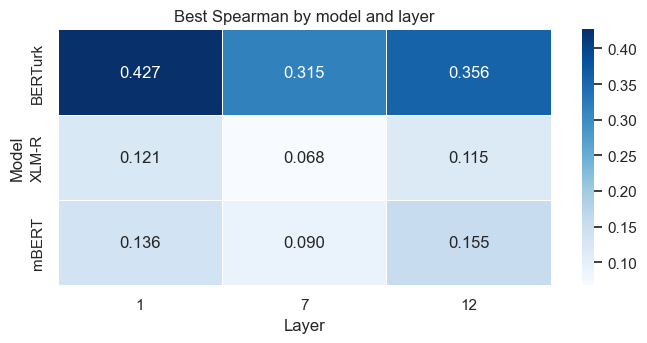

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0301-model_layer_spearman_heatmap.png


In [15]:
model_layer_heatmap = all_summary.pivot_table(
    index="model", columns="layer", values="spearman_rho", aggfunc="max"
)

plt.figure(figsize=(7, 3.6))
sns.heatmap(model_layer_heatmap, annot=True, fmt=".3f", cmap="Blues", linewidths=0.5)
plt.title("Best Spearman by model and layer")
plt.xlabel("Layer")
plt.ylabel("Model")
save_current_figure("0301-model_layer_spearman_heatmap.png")


### 2. Model x pooling heatmap

This heatmap asks whether a subtoken pooling strategy is consistently better across models after taking the best layer for each model-pooling pair.

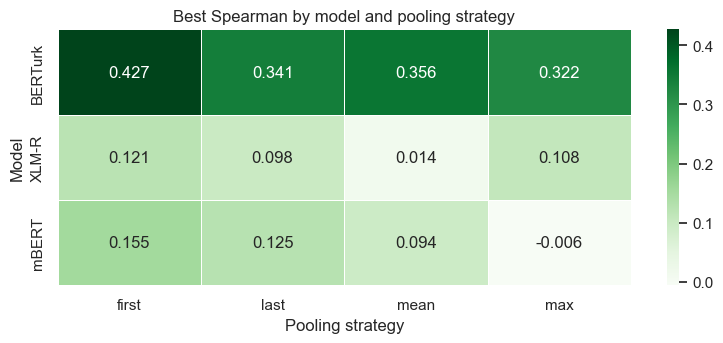

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0302-model_pooling_spearman_heatmap.png


In [16]:
model_pooling_heatmap = all_summary.pivot_table(
    index="model", columns="pooling", values="spearman_rho", aggfunc="max"
)[POOLING_STRATEGIES]

plt.figure(figsize=(8, 3.6))
sns.heatmap(model_pooling_heatmap, annot=True, fmt=".3f", cmap="Greens", linewidths=0.5)
plt.title("Best Spearman by model and pooling strategy")
plt.xlabel("Pooling strategy")
plt.ylabel("Model")
save_current_figure("0302-model_pooling_spearman_heatmap.png")


### 3. Full configuration heatmap

The full grid shows whether the best result is an isolated peak or part of a broader layer/pooling pattern.

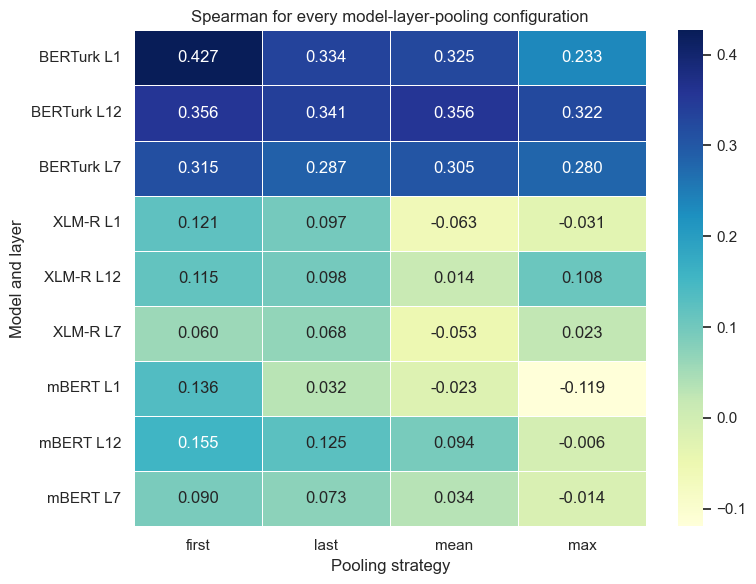

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0303-full_configuration_spearman_heatmap.png


In [17]:
full_config_heatmap = (
    all_summary.assign(model_layer=lambda df_: df_["model"] + " L" + df_["layer"].astype(str))
    .pivot_table(index="model_layer", columns="pooling", values="spearman_rho", aggfunc="first")
    [POOLING_STRATEGIES]
)

plt.figure(figsize=(8, 6))
sns.heatmap(full_config_heatmap, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5)
plt.title("Spearman for every model-layer-pooling configuration")
plt.xlabel("Pooling strategy")
plt.ylabel("Model and layer")
save_current_figure("0303-full_configuration_spearman_heatmap.png")


### 4. Clean pairs vs split pairs

This plot directly compares pairs where neither word is split with pairs where at least one word is split. A drop for split pairs would support the idea that tokenization fragmentation hurts alignment with human similarity.

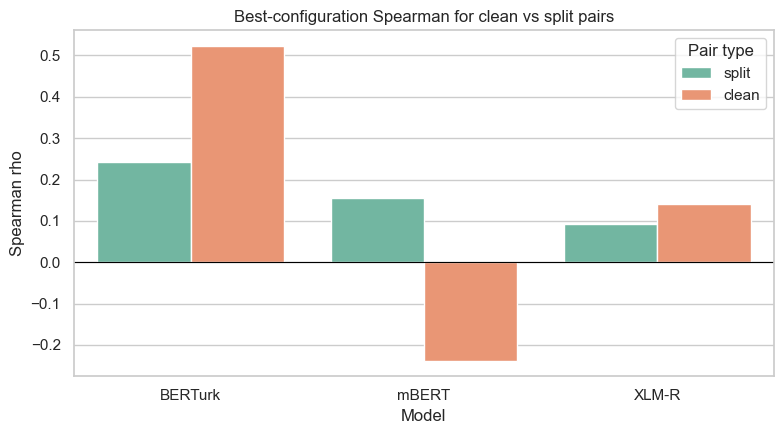

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0304-clean_vs_split_pairs_spearman.png


,model,pair_type,spearman_rho,n_pairs
0,BERTurk,split,0.241552,275.0
1,BERTurk,clean,0.522513,225.0
2,mBERT,split,0.155555,488.0
3,mBERT,clean,-0.237762,12.0
4,XLM-R,split,0.092565,407.0
5,XLM-R,clean,0.140748,93.0


In [18]:
clean_split_summary = (
    best_config_pair_rows
    .assign(pair_type=lambda df_: np.where(df_["clean_pair"], "clean", "split"))
    .pipe(grouped_spearman, ["model", "pair_type"])
)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=clean_split_summary, x="model", y="spearman_rho", hue="pair_type", palette="Set2")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Best-configuration Spearman for clean vs split pairs")
plt.xlabel("Model")
plt.ylabel("Spearman rho")
plt.legend(title="Pair type")
save_current_figure("0304-clean_vs_split_pairs_spearman.png")
clean_split_summary


### 5. Clean, one-word split, and both-words split

This breaks the previous comparison into three levels. It helps distinguish a mild single-word fragmentation effect from harder cases where both words in the pair are fragmented.

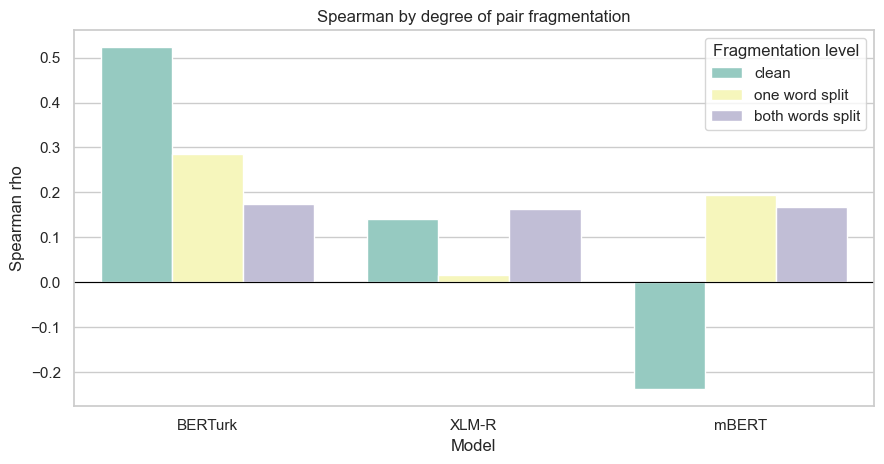

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0305-fragmentation_level_spearman.png


,model,split_level,spearman_rho,n_pairs
1,BERTurk,clean,0.522513,225.0
2,BERTurk,one word split,0.285978,170.0
0,BERTurk,both words split,0.173666,105.0
7,XLM-R,clean,0.140748,93.0
8,XLM-R,one word split,0.017114,188.0
6,XLM-R,both words split,0.162448,219.0
5,mBERT,clean,-0.237762,12.0
4,mBERT,one word split,0.194686,86.0
3,mBERT,both words split,0.166940,402.0


In [19]:
split_level_summary = (
    best_config_pair_rows
    .assign(
        split_level=lambda df_: np.select(
            [df_["clean_pair"], df_["both_words_split"]],
            ["clean", "both words split"],
            default="one word split",
        )
    )
    .pipe(grouped_spearman, ["model", "split_level"])
)
split_order = ["clean", "one word split", "both words split"]
split_level_summary["split_level"] = pd.Categorical(split_level_summary["split_level"], split_order, ordered=True)
split_level_summary = split_level_summary.sort_values(["model", "split_level"])

plt.figure(figsize=(9, 4.8))
sns.barplot(data=split_level_summary, x="model", y="spearman_rho", hue="split_level", palette="Set3")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Spearman by degree of pair fragmentation")
plt.xlabel("Model")
plt.ylabel("Spearman rho")
plt.legend(title="Fragmentation level")
save_current_figure("0305-fragmentation_level_spearman.png")
split_level_summary


### 6. Correlation by total subtoken count

This line plot checks whether performance changes as the combined number of subtokens in the pair increases.

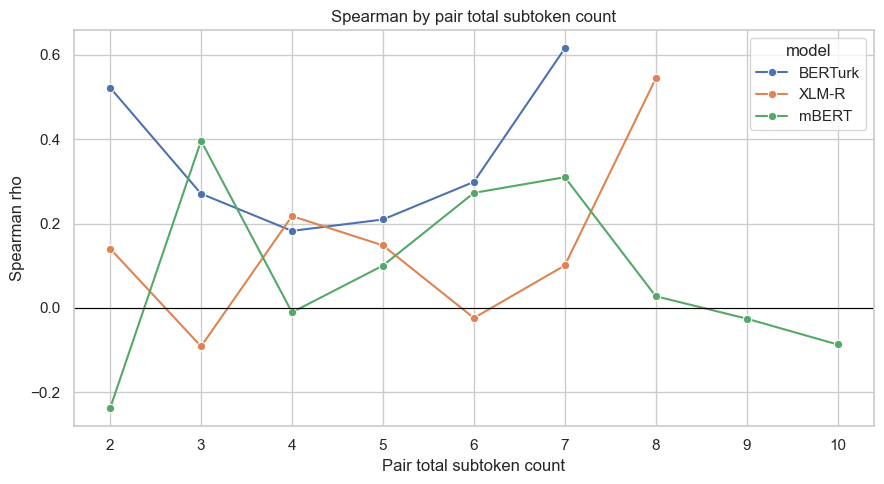

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0306-spearman_by_pair_total_subtoken_count.png


,model,pair_total_subtoken_count,spearman_rho,n_pairs
1,BERTurk,2,0.522513,225.0
3,BERTurk,3,0.270968,126.0
0,BERTurk,4,0.182852,74.0
4,BERTurk,5,0.209890,41.0
2,BERTurk,6,0.298986,22.0
5,BERTurk,7,0.615587,11.0
19,XLM-R,2,0.140748,93.0
20,XLM-R,3,-0.090969,134.0
24,XLM-R,4,0.217961,100.0
23,XLM-R,5,0.148406,79.0


In [20]:
total_complexity_summary = (
    best_config_pair_rows
    .pipe(grouped_spearman, ["model", "pair_total_subtoken_count"])
    .query("n_pairs >= 10")
    .sort_values(["model", "pair_total_subtoken_count"])
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=total_complexity_summary,
    x="pair_total_subtoken_count",
    y="spearman_rho",
    hue="model",
    marker="o",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Spearman by pair total subtoken count")
plt.xlabel("Pair total subtoken count")
plt.ylabel("Spearman rho")
save_current_figure("0306-spearman_by_pair_total_subtoken_count.png")
total_complexity_summary


### 7. Correlation by maximum word fragmentation in the pair

Total subtoken count can increase because both words are mildly split. The maximum count focuses on the most fragmented single word in each pair.

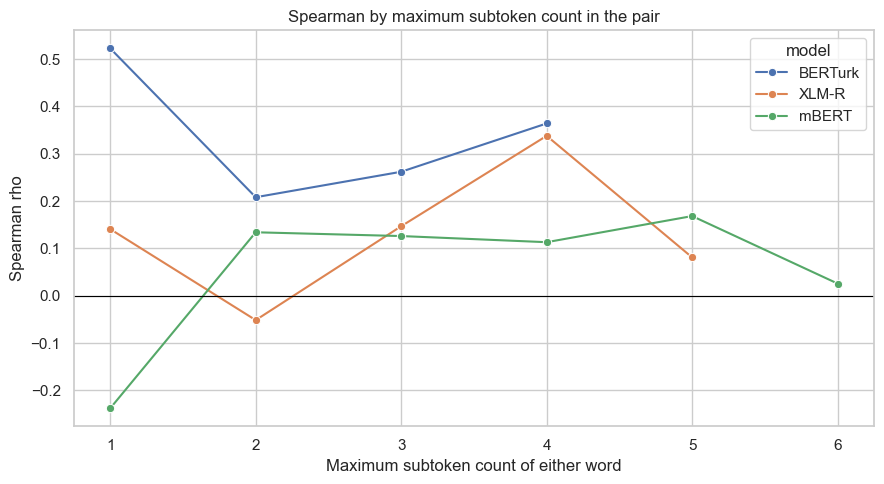

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0307-spearman_by_pair_max_subtoken_count.png


,model,pair_max_subtoken_count,spearman_rho,n_pairs
1,BERTurk,1,0.522513,225.0
0,BERTurk,2,0.208076,166.0
3,BERTurk,3,0.261898,80.0
2,BERTurk,4,0.363954,29.0
12,XLM-R,1,0.140748,93.0
13,XLM-R,2,-0.051551,199.0
11,XLM-R,3,0.146826,124.0
15,XLM-R,4,0.337775,64.0
14,XLM-R,5,0.080909,20.0
9,mBERT,1,-0.237762,12.0


In [21]:
max_complexity_summary = (
    best_config_pair_rows
    .pipe(grouped_spearman, ["model", "pair_max_subtoken_count"])
    .query("n_pairs >= 10")
    .sort_values(["model", "pair_max_subtoken_count"])
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=max_complexity_summary,
    x="pair_max_subtoken_count",
    y="spearman_rho",
    hue="model",
    marker="o",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Spearman by maximum subtoken count in the pair")
plt.xlabel("Maximum subtoken count of either word")
plt.ylabel("Spearman rho")
save_current_figure("0307-spearman_by_pair_max_subtoken_count.png")
max_complexity_summary


### 8. Model comparison: clean-minus-split difference

This summarizes the size and direction of the fragmentation effect for each model. Positive values mean the model aligns better with human judgments on clean pairs than on split pairs.

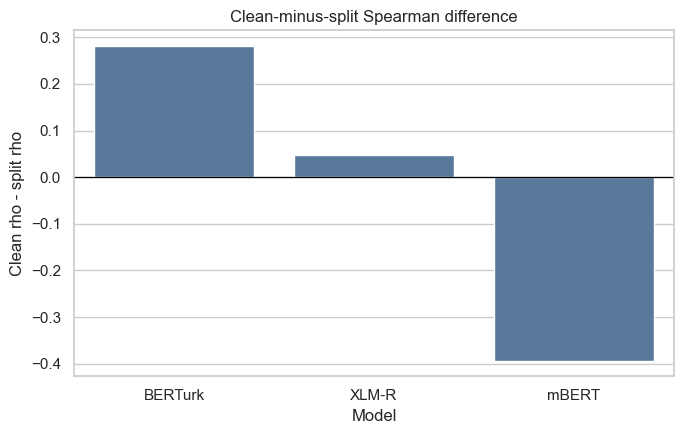

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0308-clean_minus_split_delta.png


pair_type,model,clean,split,clean_minus_split
0,BERTurk,0.522513,0.241552,0.280961
1,XLM-R,0.140748,0.092565,0.048183
2,mBERT,-0.237762,0.155555,-0.393318


In [22]:
clean_split_delta = (
    clean_split_summary.pivot(index="model", columns="pair_type", values="spearman_rho")
    .assign(clean_minus_split=lambda df_: df_.get("clean") - df_.get("split"))
    .reset_index()
)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=clean_split_delta, x="model", y="clean_minus_split", color="#4C78A8")
plt.axhline(0, color="black", linewidth=0.9)
plt.title("Clean-minus-split Spearman difference")
plt.xlabel("Model")
plt.ylabel("Clean rho - split rho")
save_current_figure("0308-clean_minus_split_delta.png")
clean_split_delta


### 9. Cosine similarity vs human similarity by fragmentation

These scatter plots show the raw pair-level relationship for each model's best configuration. The color marks total tokenization complexity; noisier or flatter clouds at higher complexity would suggest a fragmentation problem.

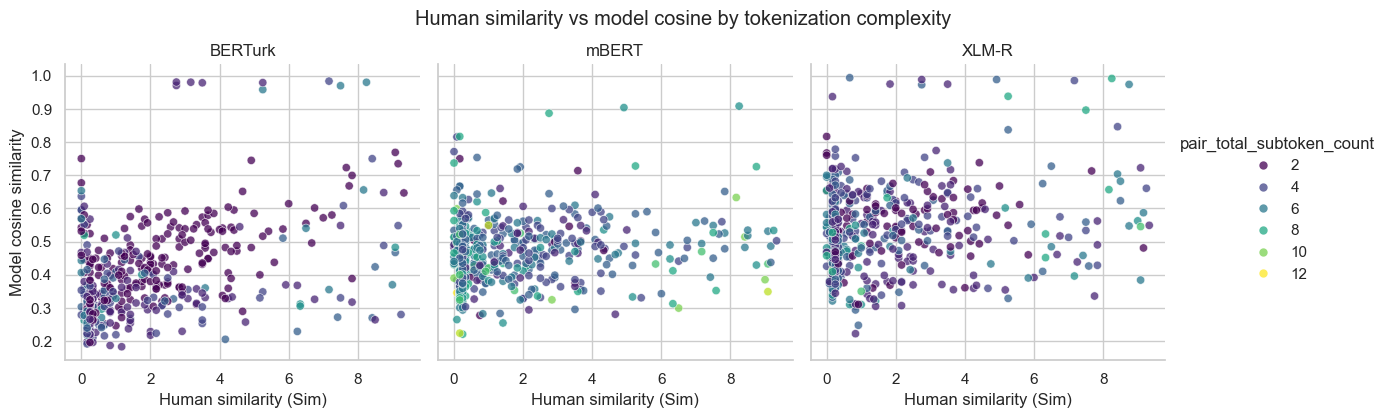

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0309-human_vs_model_similarity_by_complexity.png


In [23]:
scatter_data = best_config_pair_rows.copy()

facet = sns.relplot(
    data=scatter_data,
    x="Sim",
    y="cosine_similarity",
    hue="pair_total_subtoken_count",
    col="model",
    col_wrap=3,
    palette="viridis",
    kind="scatter",
    height=4,
    aspect=1,
    alpha=0.75,
)
facet.set_axis_labels("Human similarity (Sim)", "Model cosine similarity")
facet.set_titles("{col_name}")
facet.fig.suptitle("Human similarity vs model cosine by tokenization complexity", y=1.04)
facet.savefig(FIGURE_DIR / "0309-human_vs_model_similarity_by_complexity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {FIGURE_DIR / '0309-human_vs_model_similarity_by_complexity.png'}")


### 10. Cosine-similarity distributions for clean and split pairs

This plot checks whether fragmented pairs produce systematically different cosine-similarity distributions, independent of rank correlation.

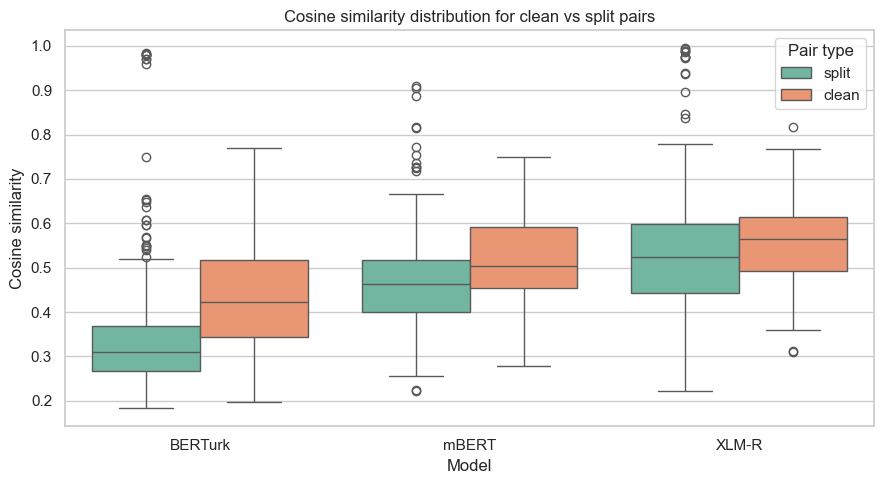

Saved figure to: /Users/nebox/Library/CloudStorage/GoogleDrive-anebieren@gmail.com/My Drive/ORTAK/nebox/Lectures/+2nd semester/Thesis/+thesis-proJect/outputs/figures/0310-cosine_distribution_clean_vs_split.png


In [24]:
box_data = best_config_pair_rows.assign(pair_type=lambda df_: np.where(df_["clean_pair"], "clean", "split"))

plt.figure(figsize=(9, 5))
sns.boxplot(data=box_data, x="model", y="cosine_similarity", hue="pair_type", palette="Set2")
plt.title("Cosine similarity distribution for clean vs split pairs")
plt.xlabel("Model")
plt.ylabel("Cosine similarity")
plt.legend(title="Pair type")
save_current_figure("0310-cosine_distribution_clean_vs_split.png")


### Figure interpretation notes

Use the heatmaps to identify the strongest model-layer-pooling settings, then use the fragmentation plots to interpret whether those settings are robust across tokenization complexity. If clean pairs consistently outperform split pairs, or if correlation declines as total/max subtoken count increases, the results support the claim that tokenization fragmentation weakens alignment with human similarity judgments. If the pattern differs by model, fragmentation should be discussed as a model-specific moderator rather than a universal failure mode.

## Best results and interpretation notes

The table below ranks configurations by Spearman correlation. Since this is still an isolated-word experiment, the results should be interpreted as model-internal lexical similarity baselines rather than contextual sentence-level performance.


In [25]:
# Rank all model-layer-pooling combinations by Spearman correlation.
best_results = all_summary.sort_values("spearman_rho", ascending=False).reset_index(drop=True)
best_results.head(15)


,model,layer,pooling,spearman_rho,p_value,n_pairs,model_name
0,BERTurk,1,first,0.426694,1.533853e-23,500,dbmdz/bert-base-turkish-cased
1,BERTurk,12,mean,0.356264,2.077249e-16,500,dbmdz/bert-base-turkish-cased
2,BERTurk,12,first,0.356035,2.177668e-16,500,dbmdz/bert-base-turkish-cased
3,BERTurk,12,last,0.340645,4.745115e-15,500,dbmdz/bert-base-turkish-cased
4,BERTurk,1,last,0.333949,1.721118e-14,500,dbmdz/bert-base-turkish-cased
5,BERTurk,1,mean,0.325226,8.800176e-14,500,dbmdz/bert-base-turkish-cased
6,BERTurk,12,max,0.322338,1.493261e-13,500,dbmdz/bert-base-turkish-cased
7,BERTurk,7,first,0.315051,5.531052e-13,500,dbmdz/bert-base-turkish-cased
8,BERTurk,7,mean,0.305104,3.120747e-12,500,dbmdz/bert-base-turkish-cased
9,BERTurk,7,last,0.287228,5.951604e-11,500,dbmdz/bert-base-turkish-cased


In [ ]:
# Keep the single best configuration for each model for quick comparison.
best_by_model = (
    all_summary.sort_values("spearman_rho", ascending=False)
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("model")
    .reset_index(drop=True)
)

best_by_model


,model,layer,pooling,spearman_rho,p_value,n_pairs,model_name
0,BERTurk,1,first,0.426694,1.533853e-23,500,dbmdz/bert-base-turkish-cased
1,XLM-R,1,first,0.121172,6.673702e-03,500,xlm-roberta-base
2,mBERT,12,first,0.154553,5.241110e-04,500,bert-base-multilingual-cased


In [27]:
top3_by_model = (
    all_summary.sort_values("spearman_rho", ascending=False)
    .groupby("model", as_index=False)
    .head(3)
    .sort_values(["model", "spearman_rho"], ascending=[True, False])
    .reset_index(drop=True)
)

top3_by_model


,model,layer,pooling,spearman_rho,p_value,n_pairs,model_name
0,BERTurk,1,first,0.426694,1.533853e-23,500,dbmdz/bert-base-turkish-cased
1,BERTurk,12,mean,0.356264,2.077249e-16,500,dbmdz/bert-base-turkish-cased
2,BERTurk,12,first,0.356035,2.177668e-16,500,dbmdz/bert-base-turkish-cased
3,XLM-R,1,first,0.121172,6.673702e-03,500,xlm-roberta-base
4,XLM-R,12,first,0.115334,9.848011e-03,500,xlm-roberta-base
5,XLM-R,12,max,0.107790,1.589795e-02,500,xlm-roberta-base
6,mBERT,12,first,0.154553,5.241110e-04,500,bert-base-multilingual-cased
7,mBERT,1,first,0.135995,2.307482e-03,500,bert-base-multilingual-cased
8,mBERT,12,last,0.125142,5.074400e-03,500,bert-base-multilingual-cased
